# LHS/Sobol'-FMQA による初期学習データ設計

このチュートリアルでは、Latin hypercube sampling (LHS) または Sobol'準ランダム列を用いて、FMQAの初期学習データを生成します。

元の`LHS-FMA.py` / `Sobol-FMA.py`と同じく、まず連続空間で点を生成してBB関数を評価し、その後に離散化・one-hot encodingを行う責務分離を採用します。

対象論文: [Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding](https://arxiv.org/abs/2605.04825)

## Goal

通常のランダム初期化では、one-hot化後の一部のbitが初期学習データに一度も現れず、対応するFMパラメータを十分に学習できない場合があります。

このNotebookでは次を確認します。

1. LHSまたはSobol'で`[0, 1)`の連続点を生成する。
2. 各変数の定義域へscaleする。
3. 連続値でBB関数を評価する。
4. 同じ連続値をbinへ離散化し、周辺bit被覆を確認する。
5. 必要な環境では、その初期データをFMQAへ渡す。

## Setup

repositoryをcloneした環境では、次を実行して依存関係を準備します。

```bash
uv sync
```

ABCI-QでFMQAまで実行する場合は、Fixstars Amplify AEへ接続できる環境が別途必要です。初期サンプリングと被覆確認だけならAEは不要です。

In [1]:
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
from amplify import FixstarsClient
from amplify_bbopt import DiscretizationSpec, RealVariable, blackbox

from amplify_bbopt_ext.initial_sampling import (
    lhs_initial_samples,
    marginal_coverage,
    sobol_initial_samples,
    warn_if_incomplete_marginal_coverage,
)

## Steps

### 1. 利用者が変更する設定

主な変更箇所はこのセルです。Sobol'は任意の正の点数を生成できますが、balance特性を保つため`n_init_data = 2**m`を推奨します。2のべき乗でない場合も処理は停止せず、警告を表示して指定点数を生成します。

In [2]:
# ===== 利用者が変更する設定 =====
n_variables = 2
bounds = (-3.0, 3.0)
n_bins = 32
sampling_method = "sobol"  # "lhs" または "sobol"
n_init_data = 32
seed = 42
scramble = True

# AEへ接続できる環境でFMQAまで実行する場合だけTrueにする。
run_fmqa = False

lower_bounds = np.full(n_variables, bounds[0])
upper_bounds = np.full(n_variables, bounds[1])

### 2. BB関数と変数を定義する

例としてRastrigin関数を使います。`initial_data`は連続値のままこのBB関数で評価します。`RealVariable`の離散化はFMQAのencodingで利用されます。

In [3]:
disc_spec = DiscretizationSpec(num_bins=n_bins)
x_list = [
    RealVariable(bounds, discretization_spec=disc_spec)
    for _ in range(n_variables)
]


def rastrigin(x: list[float] | np.ndarray) -> float:
    x_array = np.asarray(x, dtype=float)
    return float(
        10 * x_array.size
        + np.sum(x_array**2 - 10 * np.cos(2 * np.pi * x_array))
    )


@blackbox
def bb_func(input_x: list[float] = x_list) -> float:  # type: ignore
    return rastrigin(input_x)

### 3. 連続初期サンプルを生成する

返り値はshape `(n_init_data, n_variables)`の連続値です。離散候補値やone-hot vectorではありません。

In [4]:
if sampling_method == "lhs":
    initial_data = lhs_initial_samples(
        lower_bounds,
        upper_bounds,
        n_init_data,
        seed=seed,
    )
elif sampling_method == "sobol":
    initial_data = sobol_initial_samples(
        lower_bounds,
        upper_bounds,
        n_init_data,
        seed=seed,
        scramble=scramble,
    )
else:
    raise ValueError("sampling_method must be 'lhs' or 'sobol'")

print(f"Initial-data shape: {initial_data.shape}")
print(f"Minimum by variable: {initial_data.min(axis=0)}")
print(f"Maximum by variable: {initial_data.max(axis=0)}")
initial_data[:5]

Initial-data shape: (32, 2)
Minimum by variable: [-2.95727852 -2.83128108]
Maximum by variable: [2.83836193 2.83082039]


array([[-1.76881145,  0.97504785],
       [ 0.99814554, -2.59526609],
       [ 2.23399519,  2.27785952],
       [-1.47064776, -0.89221947],
       [-0.09086845,  1.98141883]])

### 4. BB関数を連続値で評価する

元コードの`scaled_vals_init`と`y_init`に相当します。離散化前の同じ点で目的関数を評価します。

In [5]:
initial_objectives = np.array([rastrigin(x) for x in initial_data])
print(f"Best initial objective: {initial_objectives.min():.6f}")
initial_objectives[:5]

Best initial objective: 5.588436


array([13.02285111, 25.99377627, 30.91700057, 24.99600656,  5.58843634])

### 5. 離散binへの写像と周辺被覆を確認する

連続値を`n_bins`個の等幅区間へ写像します。これは元コードの`np.digitize`に相当します。被覆不足時は`ValueError`で停止せず、警告を表示して処理を続けます。

In [6]:
bin_edges = np.linspace(bounds[0], bounds[1], n_bins + 1)
discrete_indices = np.clip(
    np.digitize(initial_data, bin_edges) - 1,
    0,
    n_bins - 1,
)
bin_values = [np.arange(n_bins) for _ in range(n_variables)]

coverage = warn_if_incomplete_marginal_coverage(discrete_indices, bin_values)
print(f"Complete marginal coverage: {coverage.is_complete}")
print(f"Missing counts: {[len(values) for values in coverage.missing]}")

Complete marginal coverage: True
Missing counts: [0, 0]


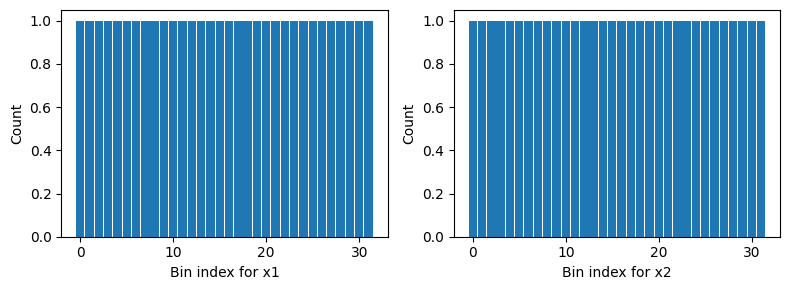

In [7]:
fig, axes = plt.subplots(
    1,
    n_variables,
    figsize=(4 * n_variables, 3),
    squeeze=False,
)
for index in range(n_variables):
    axes[0, index].hist(
        discrete_indices[:, index],
        bins=np.arange(n_bins + 1) - 0.5,
        rwidth=0.9,
    )
    axes[0, index].set_xlabel(f"Bin index for x{index + 1}")
    axes[0, index].set_ylabel("Count")
plt.tight_layout()

### 6. FMQAを実行する（ABCI-Q / Amplify AE環境のみ）

`run_fmqa=False`では、このセルは接続処理を行わず安全にskipします。AEへ接続できる環境では設定セルを`True`へ変更してください。

`LatestDatasetOptimizer`が初期値を内部でencodeするため、このNotebookでone-hot vectorを組み立てる必要はありません。

In [8]:
result = None
if run_fmqa:
    from amplify_bbopt_ext.latest_filter import run

    client = FixstarsClient()
    client.url = "http://localhost:1080"
    client.parameters.timeout = timedelta(milliseconds=1000)
    client.parameters.num_gpus = 4

    result = run(
        client=client,
        bb_func=bb_func,
        size_limit=200,
        k=8,
        n_iter=50,
        initial_data=initial_data,
        epochs=1000,
        optimizer_params={"lr": 0.01},
    )
    print(result.best.values)
    print(result.best.objective)
else:
    print("FMQA execution skipped: set run_fmqa=True in an Amplify AE environment.")

FMQA execution skipped: set run_fmqa=True in an Amplify AE environment.


## Checks

初期データだけでも、目的関数値の分布と最良値を確認できます。FMQAを実行した場合は、続けて`result.training_data`と`result.history`から最適化履歴を描画できます。

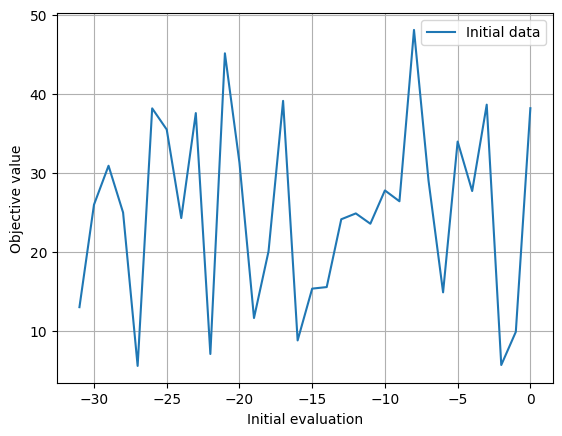

In [9]:
plt.plot(
    range(-n_init_data + 1, 1),
    initial_objectives,
    color="tab:blue",
    label="Initial data",
)
plt.xlabel("Initial evaluation")
plt.ylabel("Objective value")
plt.grid(True)
plt.legend()

## Next Steps

- `n_init_data`を増やすと被覆しやすくなりますが、BB関数の初期評価回数も増えます。
- Sobol'は任意点数に対応しますが、balance特性のため2のべき乗を推奨します。
- `scramble=True`ではseedを固定することで結果を再現できます。
- LHSとSobol'を比較するときは、BB関数、変数範囲、bin数、初期点数、FMのhyperparameter、実行回数を揃えてください。
- 離散候補値やcategoryを直接扱う場合は、`map_unit_samples_to_discrete`で単位超立方体上の点を候補値へ写像できます。

## 引用

```bibtex
@article{hayashi2026initialdata,
  title={Improving FMQA via Initial Training Data Design Considering Marginal Bit Coverage in One-Hot Encoding},
  author={Hayashi, Taiga and Seki, Yuya and Terada, Kotaro and Mukasa, Yosuke and Kikuchi, Shuta and Tanaka, Shu},
  journal={arXiv preprint arXiv:2605.04825},
  year={2026}
}
```